In [26]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import time

from numba import cuda

h = 6000
w = 3375
pixelCount = h*w
blockSize = 64
gridSize = int(pixelCount/blockSize)

def load_and_display_image(file_path):
        img = mpimg.imread(file_path)

        print(f"Image shape: {img.shape}")

        # plt.imshow(img)
        # plt.axis('off')
        # plt.show()

        return img

image_path = "image.jpg"
img = load_and_display_image(image_path)

flatten_image = np.reshape(img, (pixelCount,3))
print(flatten_image.shape)


Image shape: (6000, 3375, 3)
(20250000, 3)


CPU time: 23.618220329284668 seconds


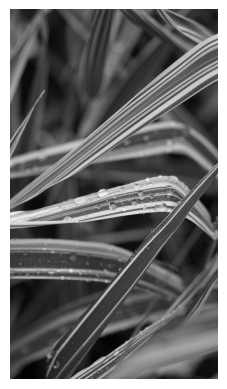

In [37]:
def grayscale_cpu(src):
    gray = np.zeros((pixelCount, 3), dtype=np.uint8)

    for i in range(pixelCount):
        g = (int(src[i, 0]) + int(src[i, 1]) + int(src[i, 2])) / 3

        gray[i, 0] = g
        gray[i, 1] = g
        gray[i, 2] = g

    return gray


start_cpu = time.time()

gray = grayscale_cpu(flatten_image)

end_cpu = time.time()

cpu_time = end_cpu - start_cpu

print("CPU time:", cpu_time, "seconds")


gray_image_cpu = gray.reshape((h, w, 3))

plt.imshow(gray_image_cpu)
plt.axis('off')
plt.show()

In [40]:
@cuda.jit
def grayscale(src, dst):
#whereareweintheinput?
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    g = np.uint8((src[tidx, 0] + src[tidx,1] + src[tidx,2])/3)
    dst[tidx,0] = dst[tidx,1] = dst[tidx,2] = g

devSrc = cuda.to_device(flatten_image)
devDst = cuda.device_array((pixelCount, 3), np.uint8)

grayscale[gridSize, blockSize](devSrc, devDst)
hostDst = devDst.copy_to_host()

start_gpu = time.time()

grayscale[gridSize, blockSize](devSrc, devDst)
hostDst = devDst.copy_to_host()

end_gpu = time.time()

gpu_time = end_gpu - start_gpu

print("GPU time:", gpu_time, "seconds")


GPU time: 0.02739405632019043 seconds


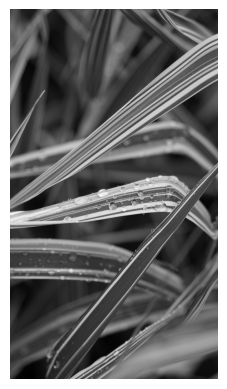

In [33]:
gray_image = hostDst.reshape((h, w, 3))

plt.imshow(gray_image)
plt.axis('off')
plt.show()

In [39]:
block_sizes = [8, 16, 32, 64, 128, 256, 512]
gpu_times = []

for blockSize in block_sizes:
    gridSize = int(pixelCount / blockSize)
    devDst = cuda.device_array((pixelCount, 3), np.uint8)

    start = time.time()

    grayscale[gridSize, blockSize](devSrc, devDst)
    hostDst = devDst.copy_to_host()

    end = time.time()

    gpu_time = end - start

    gpu_times.append(gpu_time)

    print("Block size:", blockSize,
          "Time:", gpu_time)

Block size: 8 Time: 0.0424652099609375
Block size: 16 Time: 0.03235983848571777
Block size: 32 Time: 0.028490543365478516
Block size: 64 Time: 0.028730154037475586
Block size: 128 Time: 0.027921438217163086
Block size: 256 Time: 0.027876853942871094
Block size: 512 Time: 0.028356075286865234


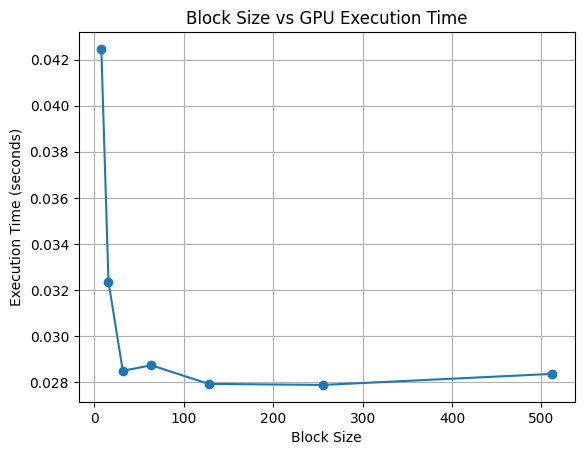

In [41]:
plt.plot(block_sizes, gpu_times, marker='o')

plt.xlabel("Block Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Block Size vs GPU Execution Time")

plt.grid()
plt.show()